# FNO and PINN on the Backwater Problem

This notebook groups the physical-model reminder from `Subject_previous_pp.pdf` together with the inverse and forward-learning experiments implemented in this repository.

## Section 1: Physical Model

For the scope of this Programming Practical, a simplified 1D permanent hydraulics model called the backwater equation model is detailed below. The objective of this algorithm is to infer the spatially-distributed Strickler coefficient, represented by the function $x \mapsto K_s(x)$ for all $x \in \Omega$.

To solve this inverse problem, an observations dataset

$$
H_{\mathrm{obs}} = \{(h_{\mathrm{obs}}^{(i)}, x_{\mathrm{obs}}^{(i)})\}_{i=1,\ldots,N_{\mathrm{obs}}}
$$

of measurements of the water height $h$ at observation points $x_{\mathrm{obs}}^{(i)}$ randomly sampled in the domain $\Omega$ is provided. The $h_{\mathrm{obs}}^{(i)}$ are obtained by integrating the backwater equation using a RK4 numerical scheme.

For the backwater equation, the following formulation is used:

$$
h'(x) = -\frac{b'(x) + j(K_s; h, x)}{1 - Fr^2(h(x))}, \qquad
j(K_s; h, x) = \frac{q^2}{K_s(x)^2 h(x)^{10/3}}, \qquad
Fr^2(h(x)) = \frac{q^2}{g h(x)^3}, \qquad \forall x \in \Omega. \tag{1}
$$

With $h(x)$, $b(x)$ and $Fr(x)$ respectively the water height, the bathymetry and the Froude number at location $x$. The following constants are also given: $q$ for the flow rate, $g$ for the gravity and $h_{BC}$ for downstream water height boundary condition (we consider the subscritical flow regime).

**Figure 1:** Subcritical regime

reference_model parameter count: total=128, trainable=120


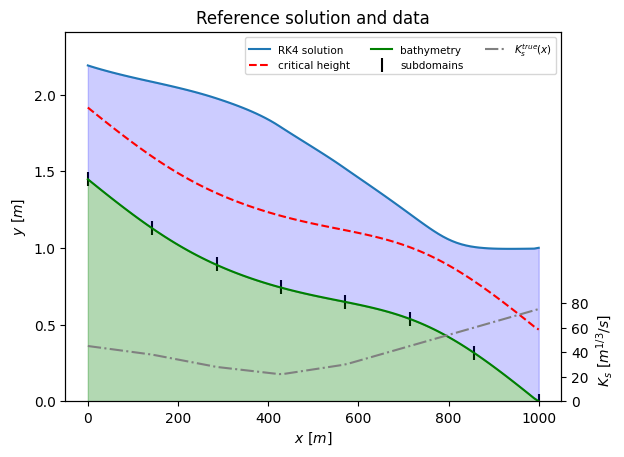

Implemented regime in this repository: subcritical


In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import torch
import matplotlib.pyplot as plt

import display
from Backwater_model import compute_ref_solution, regime
from PINN import PINN

device = torch.device("cpu")
torch.set_default_device(device)

k_true = torch.tensor([45, 38, 28, 22, 30, 45, 60, 75])
col = torch.linspace(0, 1000, 100).view(-1, 1)

reference_model = PINN(
    device=device,
    layer_sizes=[1, 40, 1],
    initial_k=k_true,
    k_ref=1.0,
    seed=0,
    trainable_k=False,
)
print(
    f"reference_model parameter count: total={sum(parameter.numel() for parameter in reference_model.parameters()):,}, "
    f"trainable={sum(parameter.numel() for parameter in reference_model.parameters() if parameter.requires_grad):,}"
)
ref_solution = compute_ref_solution(col, k=k_true, dx=10)

obs = torch.empty((0, 2))
display.display_data(col, ref_solution, obs)
print(f"Implemented regime in this repository: {regime}")

## Section 2: Physics-Informed Neural Networks

### 3.1 Physical residual

From the direct model introduced in Equation 1, the physical residual can be defined as:

$$
r(K_s; h)(x) = \ldots
$$

Once the physical residual is defined, a grid of $N_{\mathrm{col}}$ collocation points

$$
X_{\mathrm{col}} = \{x_{\mathrm{col}}^{(i)}\}_{i=1,\ldots,N_{\mathrm{col}}}
$$

can be sampled in the domain $\Omega$, regularly or not, to minimize the residual on its vertices, called collocation points. Let $\|\cdot\|$ be the norm associated to the Euclidean inner product. To embed prior physical knowledge into the training of the neural network, the following physical residual loss function can be minimized:

$$
J_{\mathrm{res}}(K_s; h) = \ldots
$$

By using Automatic Differentiation tools (AD), derivatives can be evaluated for a low computational cost and the $J_{\mathrm{res}}$ loss function can easily be evaluated at the collocation points. Since $y$ will be approximated by the output of a neural network, it is also important to note that the activation functions $\{\sigma_i\}_{i=1,\ldots,d}$ have to be chosen regular enough to be differentiable a sufficient amount of times.

To ensure that the solution satisfies at best the observations $\{h_{\mathrm{obs}}^{(i)}\}_{i=1,\ldots,N_{\mathrm{obs}}}$ distributed over the grid

$$
X_{\mathrm{obs}} = \{x_{\mathrm{obs}}^{(i)}\}_{i=1,\ldots,N_{\mathrm{obs}}}
$$

a second loss function $J_{\mathrm{obs}}$ can be defined:

$$
J_{\mathrm{obs}}(h) = \ldots
$$

With $Z$ an observation operator mapping from the physical state space to the observations space, but we won’t pay too much attention to this in the current programming practical.

Furthermore, a third loss function $J_{\mathrm{BC}}$ is introduced to ensure that the solution will satisfy the boundary condition given with the direct model defined by Equation 1.

$$
J_{\mathrm{BC}}(h(x_{\mathrm{BC}})) = \ldots
$$

With $x_{\mathrm{BC}} = \sup(\Omega)$ in subcritical regime, $x_{\mathrm{BC}} = \inf(\Omega)$ in supercritical regime and $h_{\mathrm{BC}}$ given.

To respect both physical constraints and data discrepancy during the training of $N_\theta$, the following total loss function can be minimized:

$$
J(K_s; h) = \lambda_{\mathrm{res}} J_{\mathrm{res}}(K_s; h) + \lambda_{\mathrm{obs}} J_{\mathrm{obs}}(h) + \lambda_{\mathrm{BC}} J_{\mathrm{BC}}(h(x_{\mathrm{BC}}))
$$

Where $\lambda_{\mathrm{res}}, \lambda_{\mathrm{obs}}, \lambda_{\mathrm{BC}} \in \mathbb{{R}}$ are the scalarization factors for the multi-objective optimization problem. For the sake of readability, as the two physics-informed loss functions will always be trained jointly, the $J_{\mathrm{phy}}$ loss function is defined as:

$$
\lambda_{\mathrm{phy}} J_{\mathrm{phy}}(K_s; h) = \lambda_{\mathrm{res}} J_{\mathrm{res}}(K_s; h) + \lambda_{\mathrm{BC}} J_{\mathrm{BC}}(h(x_{\mathrm{BC}}))
$$

With $\lambda_{\mathrm{phy}} \in \mathbb{{R}}$. The total loss function then becomes:

$$
J(K_s; h) = \lambda_{\mathrm{phy}} J_{\mathrm{phy}}(K_s; h) + \lambda_{\mathrm{obs}} J_{\mathrm{obs}}(h)
$$

### 3.2 Neural Networks with physical constraints

Let’s consider a Neural Network $N_\theta$ of the following form:

$$
N_\theta : x \mapsto \tilde{{h}}^{{(\theta)}}(x)
$$

The training of $N_\theta$ as a Physics-Informed Neural Networks to infer the spatially-distributed Strickler coefficient $K_s(x)$ then refers to the following optimization problem:

$$
(K_s^*, \theta^*) = \arg\min_{{K_s, \theta}} \left[ \lambda_{{\mathrm{{phy}}}} J_{{\mathrm{{phy}}}}(K_s; \tilde{{h}}^{{(\theta)}}) + \lambda_{{\mathrm{{obs}}}} J_{{\mathrm{{obs}}}}(\tilde{{h}}^{{(\theta)}}) \right]
$$

The architecture of the PINN is represented in Figure 3.

In the case of the backwater equation, the gradient norm $\left\|\frac{{\partial J}}{{\partial K_s}}\right\|$ is negligible in comparison to $\left\|\frac{{\partial J}}{{\partial \theta}}\right\|$ so during the minimization, the physical parameter $K_s$ has no influence and thus gets almost no update. To overcome this issue, an alternating minimization strategy is used:

$$
\begin{dcases}
\theta^{{(i+1)}} = \arg\min_{{\theta}} \left[ \lambda_{{\mathrm{{phy}}}} J_{{\mathrm{{phy}}}}(K_s^{{(i)}}; \tilde{{h}}^{{(\theta^{{(i)}})}}) + \lambda_{{\mathrm{{obs}}}} J_{{\mathrm{{obs}}}}(\tilde{{h}}^{{(\theta^{{(i)}})}}) \right] \\
K_s^{{(i+1)}} = \arg\min_{{K_s}} J_{{\mathrm{{res}}}}(K_s, \tilde{{h}}^{{(\theta^{{(i+1)}})}})
\end{dcases}
\qquad i = 0, \ldots, N
$$

In addition to that, a pre-training where only the $J_{\mathrm{obs}}$ functional is minimized is used before the alternating minimization to begin the minimization of $J_{\mathrm{res}}$ in a good neighborhood of the physical solution.

**Figure 3:** PINN for $K_s$ inference on backwater equation


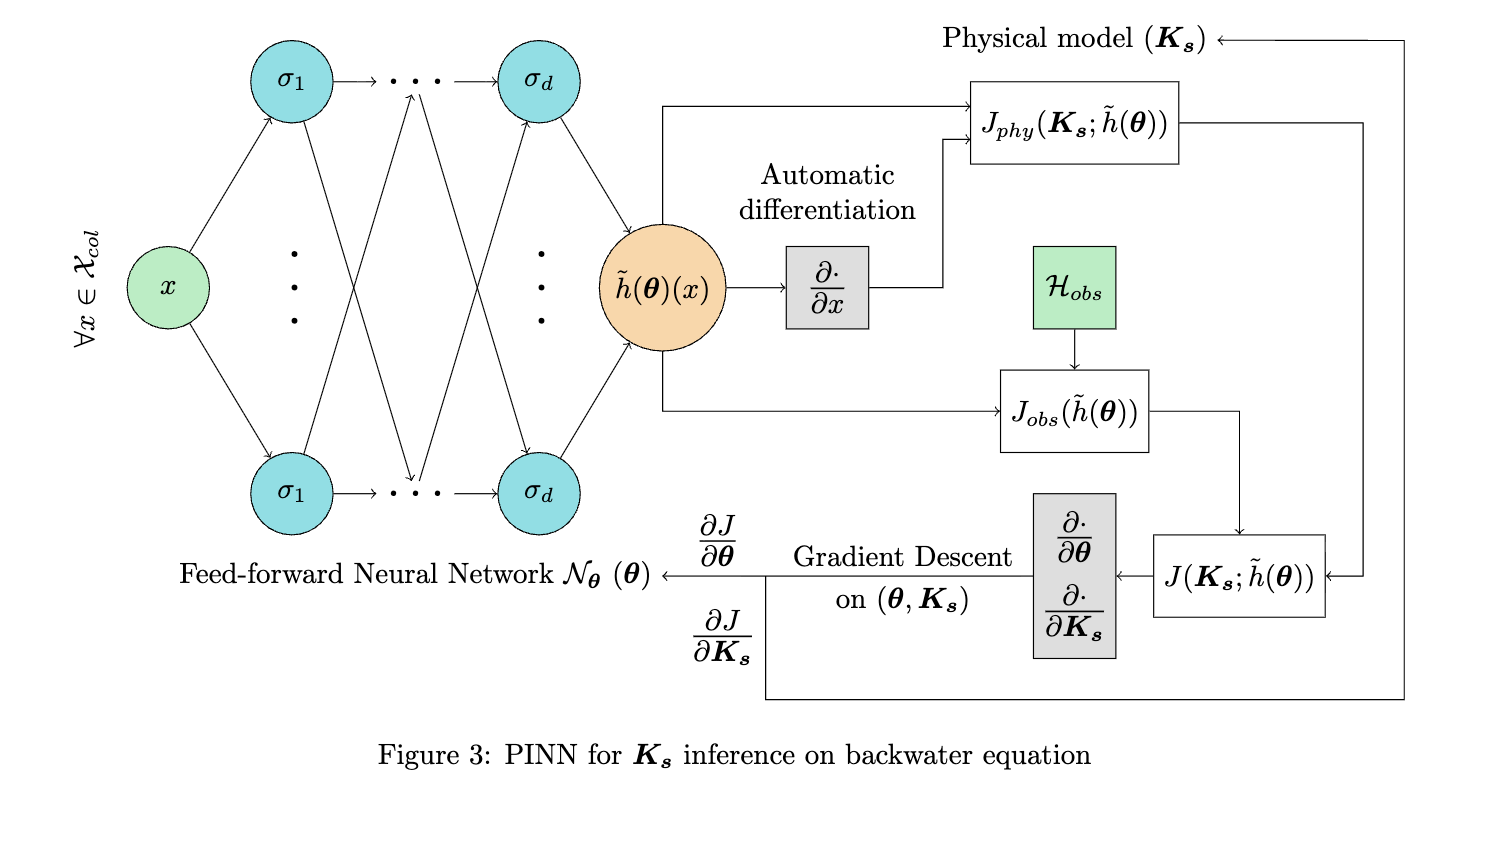

## Section 3: PINNs for Bathymetry Calibration (Inverse Porblem)

First, we use PINNs to perform inverse problem. The objective is to estimate the unknown spatially distributed `K_s` field from water-height observations while enforcing the backwater PDE.

In [2]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys

ROOT = Path.cwd()
SRC = ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import numpy as np
import matplotlib.pyplot as plt
import torch
from pprint import pprint

import display
from Backwater_model import Ks_function, compute_ref_solution
from normalization import normalize_input
from PINN import PINN
from trainer import PITrainer

print('Pytorch version:', torch.__version__)

Pytorch version: 2.11.0


### Setup

We use an 8-parameter `K_s` representation.

Running on cpu!


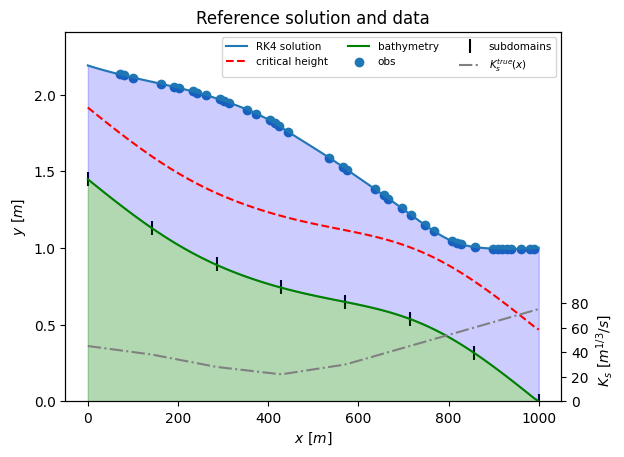

In [3]:
device = torch.device("cpu")
torch.set_default_device(device)
print(f"Running on {device}!")

k_true = torch.tensor([45, 38, 28, 22, 30, 45, 60, 75])
col = torch.linspace(0, 1000, 100).view(-1, 1)

ref_solution = compute_ref_solution(col, k=k_true, dx=10)

torch.manual_seed(0)
random_indices = torch.randperm(ref_solution["domain"].shape[0])[:40]
obs = torch.hstack((ref_solution["domain"], ref_solution["solution"]))[random_indices]
display.display_data(col, ref_solution, obs)

### PINN Inverse Calibration

This reproduces the original PP1 workflow: pre-training on observations, then alternating optimization on the network weights and on `K_s`.

pinn_inverse parameter count: total=128, trainable=128
##################################################
Processing evaluation 50
-------------------------
J           = 2.50e-02 (residual : 0.00e+00, obs : 2.22e-02, BC : 2.73e-03)
||grad(J)|| = 1.01e-02
parameter    = tensor([40., 40., 40., 40., 40., 40., 40., 40.])
time         = 1.86 s
##################################################
Processing evaluation 100
-------------------------
J           = 2.96e-02 (residual : 0.00e+00, obs : 2.93e-02, BC : 3.92e-04)
||grad(J)|| = 9.28e-01
parameter    = tensor([40., 40., 40., 40., 40., 40., 40., 40.])
time         = 2.13 s
##################################################
Processing evaluation 150
-------------------------
J           = 1.24e-03 (residual : 5.36e-04, obs : 6.71e-04, BC : 3.51e-05)
||grad(J)|| = 1.35e-02
parameter    = tensor([32.9365, 23.3702, 24.2142, 37.4264, 54.8960, 53.4439, 38.1622, 35.7337])
time         = 2.30 s
##################################################

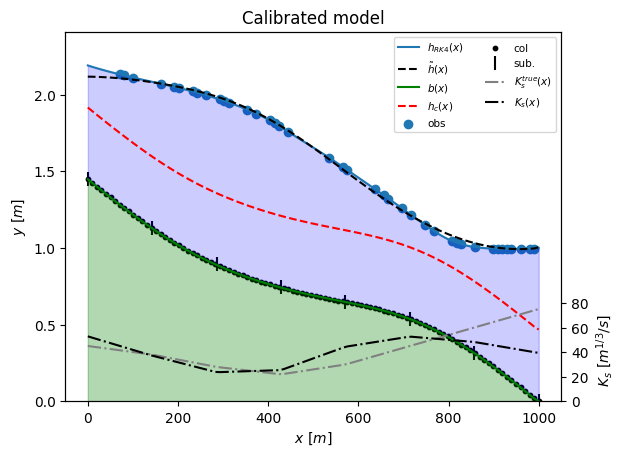

##################################################
Processing evaluation 250
-------------------------
J           = 7.11e-04 (residual : 5.84e-04, obs : 1.26e-04, BC : 5.41e-07)
||grad(J)|| = 1.00e-03
parameter    = tensor([58.8674, 41.8019, 30.3952, 20.9365, 13.6748, 47.4247, 56.3448, 45.7133])
time         = 3.00 s
##################################################
Processing evaluation 300
-------------------------
J           = 1.05e-04 (residual : 2.47e-05, obs : 7.97e-05, BC : 8.80e-07)
||grad(J)|| = 7.32e-05
parameter    = tensor([58.6027, 41.4076, 30.1700, 23.0684, 23.6497, 47.8954, 56.2450, 46.0215])
time         = 3.20 s
##################################################
Processing evaluation 350
-------------------------
J           = 8.93e-05 (residual : 9.10e-06, obs : 7.91e-05, BC : 1.10e-06)
||grad(J)|| = 2.06e-03
parameter    = tensor([57.6852, 39.8718, 28.7876, 22.2033, 27.9086, 48.1336, 56.3538, 47.4275])
time         = 3.45 s
########################################

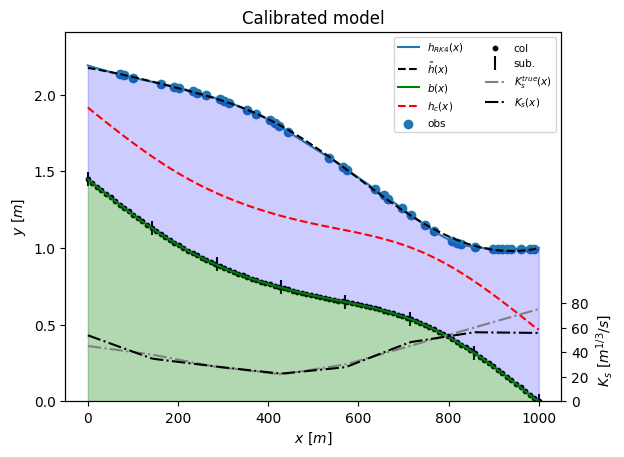

##################################################
Processing evaluation 450
-------------------------
J           = 8.33e-05 (residual : 4.18e-06, obs : 7.80e-05, BC : 1.17e-06)
||grad(J)|| = 1.41e-04
parameter    = tensor([53.1229, 37.1057, 28.4284, 22.2895, 27.3655, 48.0984, 55.2735, 60.8098])
time         = 4.26 s
##################################################
Processing evaluation 500
-------------------------
J           = 8.30e-05 (residual : 3.89e-06, obs : 7.80e-05, BC : 1.11e-06)
||grad(J)|| = 2.93e-04
parameter    = tensor([52.8520, 35.9688, 28.0444, 22.5188, 27.7617, 48.1010, 55.3823, 62.1064])
time         = 4.50 s
##################################################
Final variable RMSE : 9.60e-03
##################################################


In [4]:
# Step 1: build the model.
pinn_inverse = PINN(
    device=device,
    layer_sizes=[1, 40, 1],
    initial_k=40 * torch.ones_like(k_true),
    k_ref=40,
    seed=0,
    trainable_k=True,
)
print(
    f"pinn_inverse parameter count: total={sum(parameter.numel() for parameter in pinn_inverse.parameters()):,}, "
    f"trainable={sum(parameter.numel() for parameter in pinn_inverse.parameters() if parameter.requires_grad):,}"
)
pinn_inverse_trainer = PITrainer(train_k=True)
# Step 2: train the model.
pinn_inverse_result = pinn_inverse_trainer.fit(
    pinn_inverse,
    col,
    obs,
    ref_solution,
    pre_train_iter=100,
    alter_steps=8,
    alter_freq=(40, 10),
    scale_losses=True,
    display_freq=(50, 200),
)
# Step 3: evaluate the model.
pinn_inverse_rmse = display.display_training(pinn_inverse, col, ref_solution)

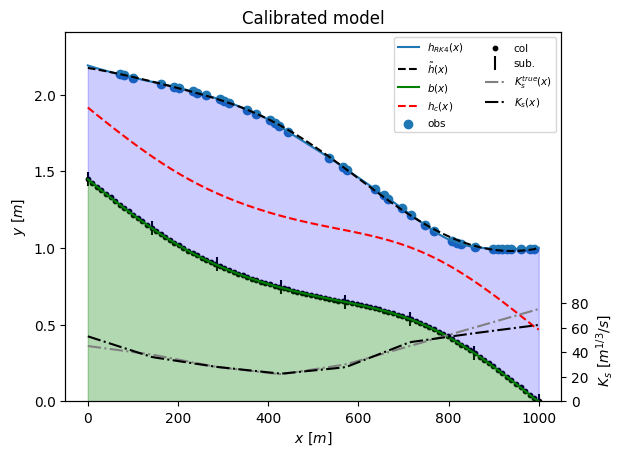

In [5]:
display.display_results(pinn_inverse, col, ref_solution, obs, plot_col=True)

### Compare the Recovered `K_s(x)` and `h(x)`

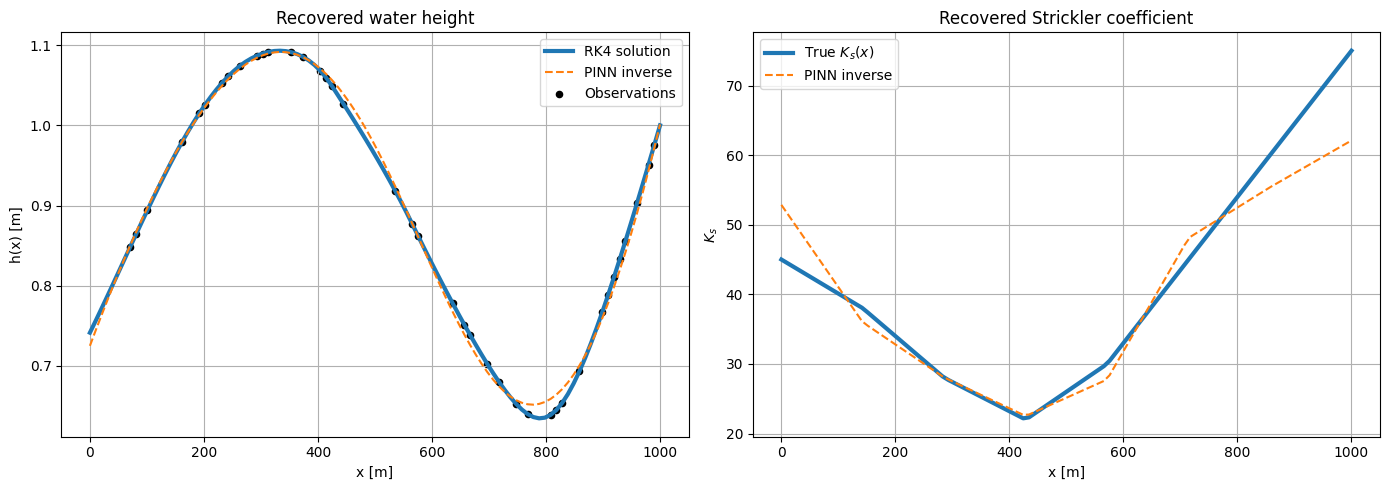

In [6]:
x = ref_solution["domain"].numpy().flatten()
h_true = ref_solution["solution"].numpy().flatten()
ks_true = ref_solution["parameter_function"].numpy().flatten()

with torch.no_grad():
    h_pinn = (
        pinn_inverse(normalize_input(ref_solution["domain"], col)).numpy().flatten()
    )
    ks_pinn = (
        Ks_function(ref_solution["domain"], pinn_inverse.parameter_values(), col)
        .numpy()
        .flatten()
    )

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(x, h_true, label="RK4 solution", linewidth=3)
axes[0].plot(x, h_pinn, "--", label="PINN inverse")
axes[0].scatter(
    obs[:, 0].numpy(),
    obs[:, 1].numpy(),
    s=20,
    c="k",
    label="Observations",
)
axes[0].set_title("Recovered water height")
axes[0].set_xlabel("x [m]")
axes[0].set_ylabel("h(x) [m]")
axes[0].grid(True)
axes[0].legend()

axes[1].plot(x, ks_true, label="True $K_s(x)$", linewidth=3)
axes[1].plot(x, ks_pinn, "--", label="PINN inverse")
axes[1].set_title("Recovered Strickler coefficient")
axes[1].set_xlabel("x [m]")
axes[1].set_ylabel("$K_s$")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

In [7]:
def relative_parameter_error(estimate, truth):
    return np.linalg.norm(estimate - truth, ord=2) / np.linalg.norm(truth, ord=2)


comparison = {
    "PINN_solution_rmse": pinn_inverse_rmse,
    "PINN_parameter_error": relative_parameter_error(ks_pinn, ks_true),
}
pprint(comparison)

{'PINN_parameter_error': np.float32(0.094659135),
 'PINN_solution_rmse': np.float32(0.009597255)}


### Sensitivity to the Number of Observations

The following study has been conducted with $N_{obs} = 40$. It is interesting to study the sensitivity of the reconstruction error to the number of observation $N_{obs}$. In the following, we observe the error for $N_{obs} \in$ `[10, 40, 80, 120]`.

##########################################################################################
Training for 10 obervation
model parameter count: total=128, trainable=128


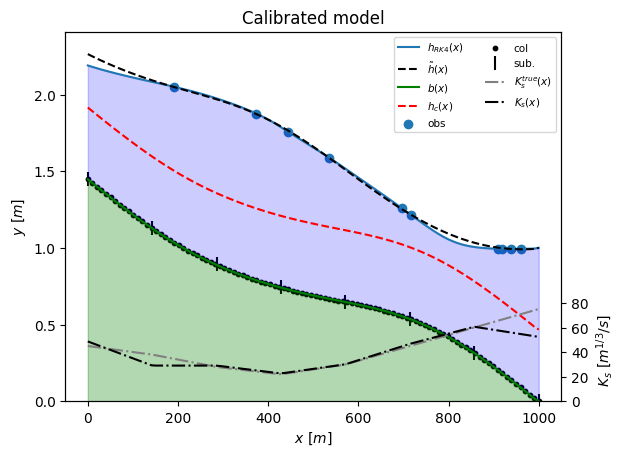

{'parameter_error': np.float32(0.13260508),
 'solution_error': np.float32(0.023706378)}
##########################################################################################
Training for 40 obervation
model parameter count: total=128, trainable=128


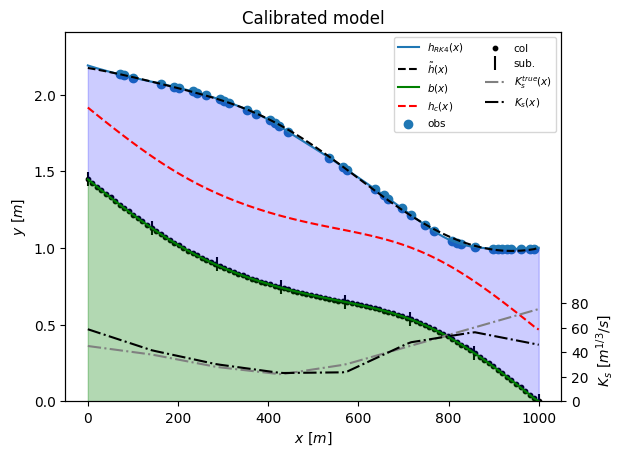

{'parameter_error': np.float32(0.18982771),
 'solution_error': np.float32(0.009848652)}
##########################################################################################
Training for 80 obervation
model parameter count: total=128, trainable=128


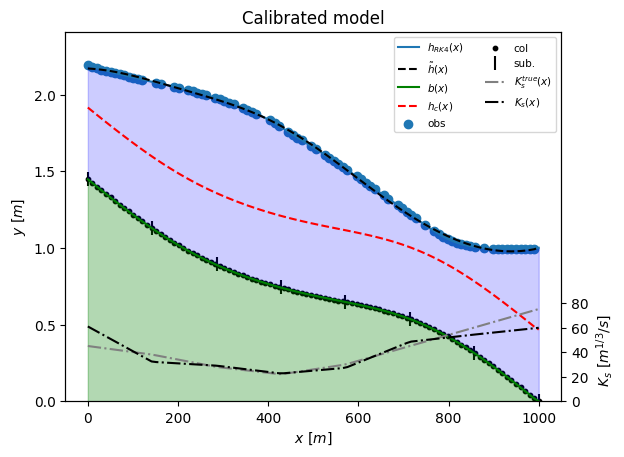

{'parameter_error': np.float32(0.13013767),
 'solution_error': np.float32(0.011031789)}
##########################################################################################
Training for 120 obervation
model parameter count: total=128, trainable=128


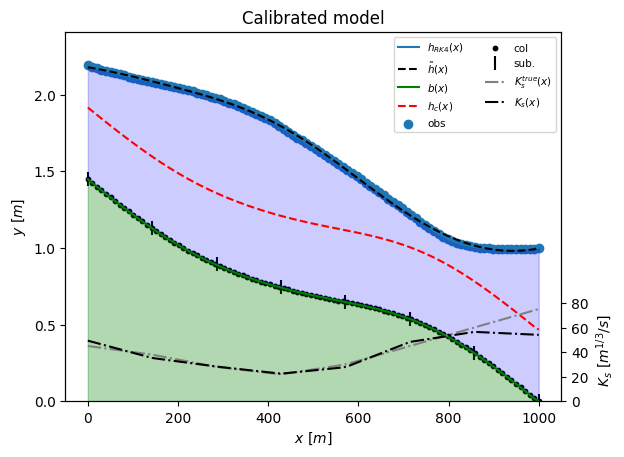

{'parameter_error': np.float32(0.12522759),
 'solution_error': np.float32(0.00964023)}


In [22]:
seed = 0
n_obs_values = [10, 40, 80, 120]
pinn_sensitivity = {}
for n_obs in n_obs_values:
    print("#" * 90)
    print(f"Training for {n_obs} obervation")
    model = PINN(
        device=device,
        layer_sizes=[1, 40, 1],
        initial_k=40 * torch.ones_like(k_true),
        k_ref = 40,
        seed=seed,
        trainable_k=True,
    )
    print(
        f"model parameter count: total={sum(parameter.numel() for parameter in model.parameters()):,}, "
        f"trainable={sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad):,}"
    )
    torch.manual_seed(seed)
    random_indices = torch.randperm(ref_solution["domain"].shape[0])[:n_obs]
    local_obs = torch.hstack((ref_solution["domain"], ref_solution["solution"]))[
        random_indices
    ]
    trainer = PITrainer(train_k=True)
    trainer.fit(
        model,
        col,
        local_obs,
        ref_solution,
        pre_train_iter=100,
        alter_steps=4,
        alter_freq=(40, 10),
        scale_losses=True,
        display_freq=(500, 300),
    )
    with torch.no_grad():
        ks_est = (
            Ks_function(ref_solution["domain"], model.parameter_values(), col)
            .numpy()
            .flatten()
        )
        h_est = model(normalize_input(ref_solution["domain"], col)).numpy().flatten()
    pinn_sensitivity[n_obs] = {
        "parameter_error": relative_parameter_error(ks_est, ks_true),
        "solution_error": relative_parameter_error(h_est, h_true),
    }
    pprint(pinn_sensitivity[n_obs])

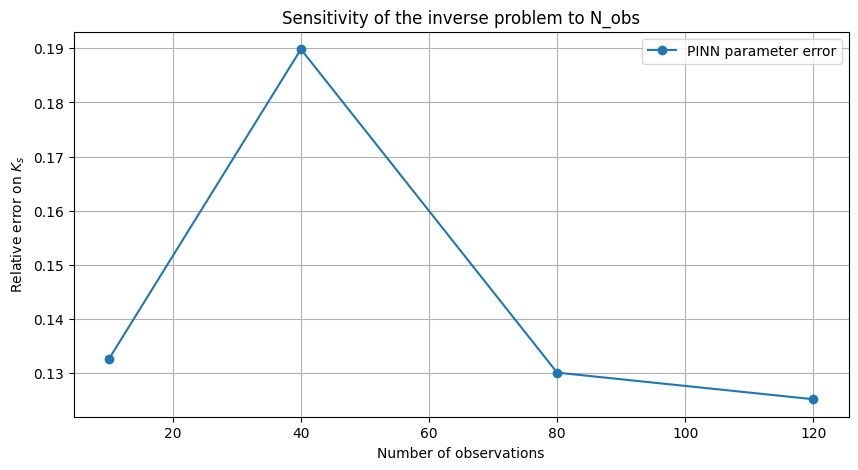

In [23]:
plt.figure(figsize=(10, 5))
plt.plot(
    n_obs_values,
    [pinn_sensitivity[n]["parameter_error"] for n in n_obs_values],
    "o-",
    label="PINN parameter error",
)
plt.xlabel("Number of observations")
plt.ylabel("Relative error on $K_s$")
plt.title("Sensitivity of the inverse problem to N_obs")
plt.grid(True)
plt.legend()
plt.show()

# Section 4: Learning the PDE Solution: FNO vs MLP vs PINN

In this section, you will compare three models:

- FNO trained from observations
- MLP trained from observations only
- PINN trained from observations and PDE residual

In [10]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys

ROOT = Path.cwd()
SRC = ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import numpy as np
import matplotlib.pyplot as plt
import torch

import display
from Backwater_model import compute_ref_solution
from FNO import FNO
from MLP import MLP
from normalization import normalize_input
from PINN import PINN
from trainer import PITrainer, Trainer

print('Pytorch version:', torch.__version__)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Pytorch version: 2.11.0


### Setup

Here, we define the reference backwater configuration.

**Exercice:** Since we are using FNOs in this comparison study, how should you define observation points?

Running on cpu!
reference_model parameter count: total=128, trainable=120


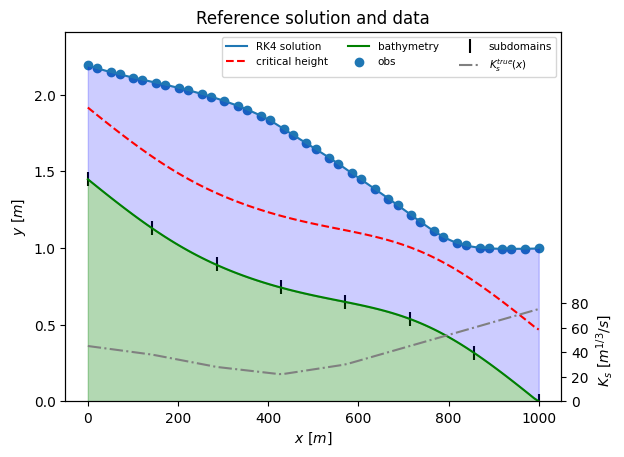

In [11]:
device = torch.device("cpu")
torch.set_default_device(device)
print(f"Running on {device}!")

k_true = torch.tensor([45, 38, 28, 22, 30, 45, 60, 75])
col = torch.linspace(0, 1000, 100).view(-1, 1)
reference_model = PINN(
    device=device,
    layer_sizes=[1, 40, 1],
    initial_k=k_true,
    k_ref=1.0,
    seed=0,
    trainable_k=False,
)
print(
    f"reference_model parameter count: total={sum(parameter.numel() for parameter in reference_model.parameters()):,}, "
    f"trainable={sum(parameter.numel() for parameter in reference_model.parameters() if parameter.requires_grad):,}"
)
ref_solution = compute_ref_solution(col, k=k_true, dx=10)

n_domain = ref_solution["domain"].shape[0]
grid_indices = torch.linspace(0, n_domain - 1, steps=40).long()
obs = torch.hstack((ref_solution["domain"], ref_solution["solution"]))[grid_indices]
display.display_data(col, ref_solution, obs)

### FNO Baseline

**Exercice:** Complete the missing parts of the FNO architecture in `FNO.py`

fno_model parameter count: total=606, trainable=606
##################################################
Processing iteration 50
-------------------------
J_obs       = 1.18e-03
||grad(J)|| = 1.26e-01
time        = 0.40 s
##################################################
Processing iteration 100
-------------------------
J_obs       = 3.65e-05
||grad(J)|| = 4.80e-03
time        = 0.85 s
##################################################
Processing iteration 150
-------------------------
J_obs       = 1.55e-05
||grad(J)|| = 1.81e-03
time        = 1.21 s
##################################################
Processing iteration 200
-------------------------
J_obs       = 1.16e-05
||grad(J)|| = 7.98e-04
time        = 1.53 s


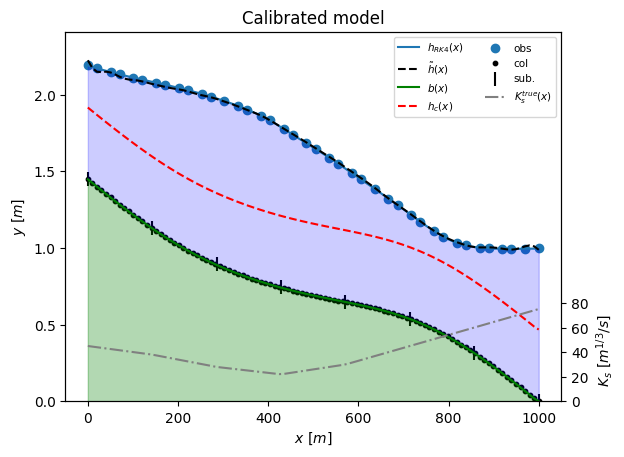

##################################################
Processing iteration 250
-------------------------
J_obs       = 8.90e-06
||grad(J)|| = 7.68e-04
time        = 2.13 s
##################################################
Processing iteration 300
-------------------------
J_obs       = 7.30e-06
||grad(J)|| = 6.82e-04
time        = 2.49 s
##################################################
Final variable RMSE : 9.64e-03
##################################################


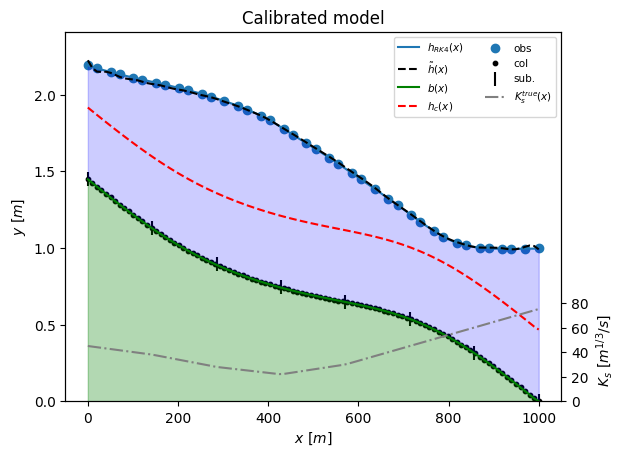

In [12]:
# Step 1: build the model.
fno_model = FNO(
    device=device,
    n_modes_layer_1=10,
    n_modes_layer_2=10,
    n_channels=5,
    seed=0,
)
print(
    f"fno_model parameter count: total={sum(parameter.numel() for parameter in fno_model.parameters()):,}, "
    f"trainable={sum(parameter.numel() for parameter in fno_model.parameters() if parameter.requires_grad):,}"
)
fno_trainer = Trainer()
# Step 2: train the model.
fno_result = fno_trainer.fit(
    fno_model,
    col,
    obs,
    ref_solution,
    n_iter=300,
    lr=1e-2,
    display_freq=(50, 200),
)
# Step 3: evaluate the model.
fno_rmse = display.display_training(fno_model, col, ref_solution)
display.display_results(fno_model, col, ref_solution, obs, plot_col=True)

### MLP Without Physics Loss

A dedicated observation-driven `MLP` is used for the non-physics baseline. The network is the same as PINN but without residual and boundary loss. Hence, we use a simple `Trainer` (same as `FNO`) but with `lbfgs` optimizer (same as PINN).

mlp_model parameter count: total=120, trainable=120
##################################################
Processing evaluation 50
-------------------------
J_obs       = 1.48e-02
||grad(J)|| = 1.90e-02
time        = 0.08 s
##################################################
Processing evaluation 100
-------------------------
J_obs       = 5.29e-03
||grad(J)|| = 1.32e-02
time        = 0.21 s
##################################################
Processing evaluation 150
-------------------------
J_obs       = 3.58e-03
||grad(J)|| = 3.71e-02
time        = 0.31 s
##################################################
Processing evaluation 200
-------------------------
J_obs       = 2.52e-03
||grad(J)|| = 1.11e-01
time        = 0.49 s


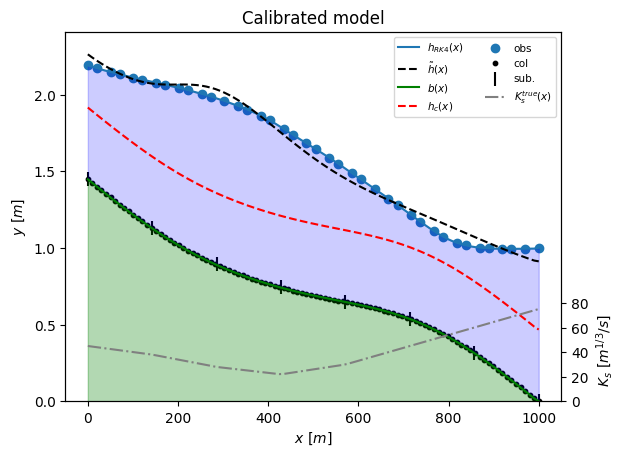

##################################################
Processing evaluation 250
-------------------------
J_obs       = 5.13e-04
||grad(J)|| = 7.44e-03
time        = 1.20 s
##################################################
Processing evaluation 300
-------------------------
J_obs       = 7.30e-05
||grad(J)|| = 7.17e-03
time        = 1.39 s
##################################################
Final variable RMSE : 8.71e-03
##################################################


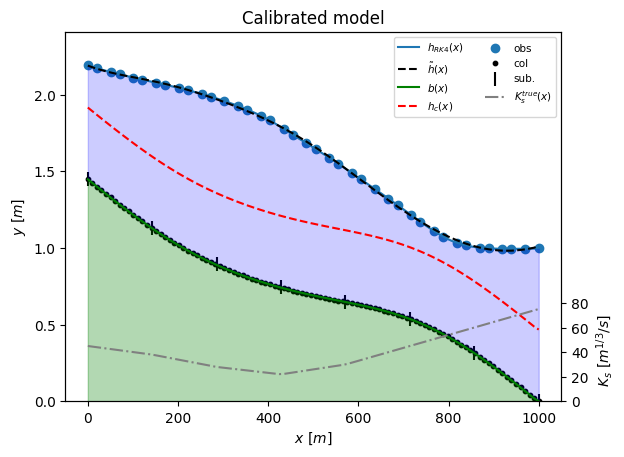

In [13]:
# Step 1: build the model.
mlp_model = MLP(
    device=device,
    layer_sizes=[1, 40, 1],
    seed=0,
)
print(
    f"mlp_model parameter count: total={sum(parameter.numel() for parameter in mlp_model.parameters()):,}, "
    f"trainable={sum(parameter.numel() for parameter in mlp_model.parameters() if parameter.requires_grad):,}"
)
mlp_trainer = Trainer(optimizer_name="lbfgs")
# Step 2: train the model.
mlp_result = mlp_trainer.fit(
    mlp_model,
    col,
    obs,
    ref_solution,
    n_iter=300,
    lr=1e-2,
    display_freq=(50, 200),
)
# Step 3: evaluate the model.
mlp_rmse = display.display_training(mlp_model, col, ref_solution)
display.display_results(mlp_model, col, ref_solution, obs, plot_col=True)

### PINN With Physics Loss

The residual and boundary-condition terms are now activated during training by using `PITrainer`.

pinn_model parameter count: total=128, trainable=120
##################################################
Processing evaluation 50
-------------------------
J           = 2.75e-02 (residual : 0.00e+00, obs : 2.52e-02, BC : 2.24e-03)
||grad(J)|| = 8.67e-03
parameter    = tensor([45., 38., 28., 22., 30., 45., 60., 75.])
time         = 0.30 s
##################################################
Processing evaluation 100
-------------------------
J           = 1.86e-02 (residual : 0.00e+00, obs : 1.86e-02, BC : 1.72e-06)
||grad(J)|| = 3.53e-01
parameter    = tensor([45., 38., 28., 22., 30., 45., 60., 75.])
time         = 0.57 s
##################################################
Processing evaluation 150
-------------------------
J           = 2.14e-03 (residual : 3.14e-05, obs : 1.97e-03, BC : 1.39e-04)
||grad(J)|| = 1.23e-02
parameter    = tensor([45., 38., 28., 22., 30., 45., 60., 75.])
time         = 0.79 s
##################################################
Processing evaluation 200
-------

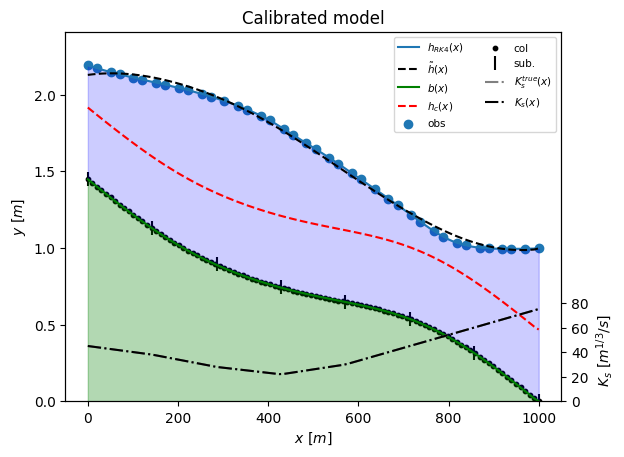

##################################################
Processing evaluation 250
-------------------------
J           = 9.48e-05 (residual : 5.60e-06, obs : 8.89e-05, BC : 2.98e-07)
||grad(J)|| = 2.81e-03
parameter    = tensor([45., 38., 28., 22., 30., 45., 60., 75.])
time         = 1.51 s
##################################################
Final variable RMSE : 9.75e-03
##################################################


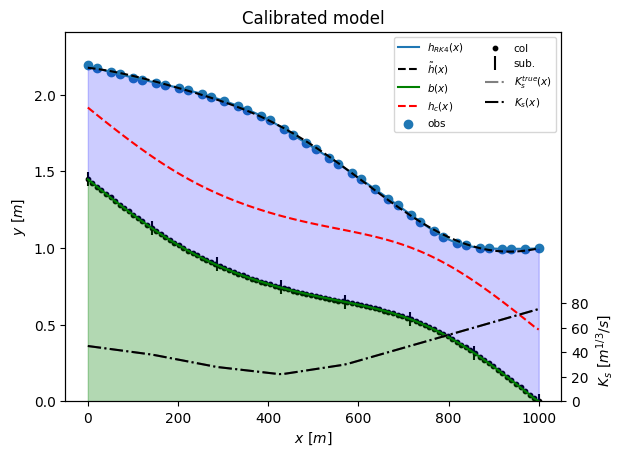

In [14]:
# Step 1: build the model.
pinn_model = PINN(
    device=device,
    layer_sizes=[1, 40, 1],
    initial_k=k_true,
    k_ref=1.0,
    seed=0,
    trainable_k=False,
)
print(
    f"pinn_model parameter count: total={sum(parameter.numel() for parameter in pinn_model.parameters()):,}, "
    f"trainable={sum(parameter.numel() for parameter in pinn_model.parameters() if parameter.requires_grad):,}"
)
pinn_trainer = PITrainer(train_k=False)
# Step 2: train the model.
pinn_result = pinn_trainer.fit(
    pinn_model,
    col,
    obs,
    ref_solution,
    pre_train_iter=100,
    alter_steps=4,
    alter_freq=(40, 10),
    scale_losses=True,
    display_freq=(50, 200),
)
# Step 3: evaluate the model.
pinn_rmse = display.display_training(pinn_model, col, ref_solution)
display.display_results(pinn_model, col, ref_solution, obs, plot_col=True)

### Direct Comparison

Compare the three predictions on the same test case.

In [15]:
rmse_table = {
    "FNO": fno_rmse,
    "MLP without PINN": mlp_rmse,
    "MLP with PINN": pinn_rmse,
}
rmse_table

{'FNO': np.float32(0.0096367365),
 'MLP without PINN': np.float32(0.008708402),
 'MLP with PINN': np.float32(0.0097518405)}

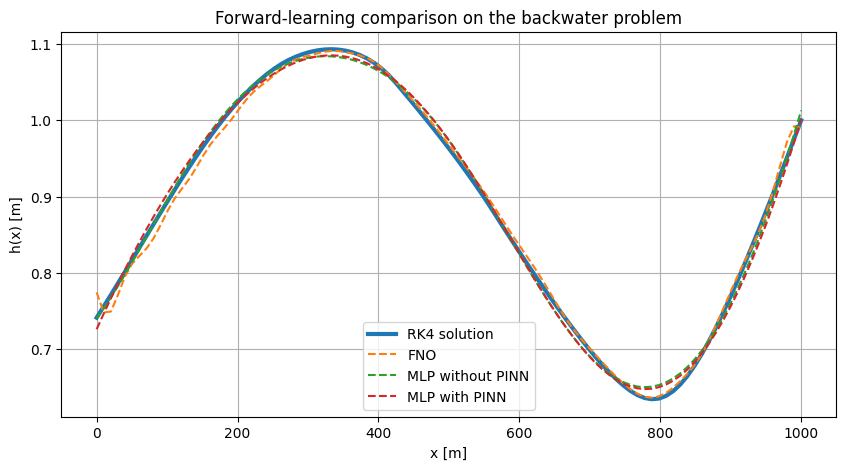

In [16]:
x = col.numpy().flatten()
h_true = ref_solution["solution"].numpy().flatten()
with torch.no_grad():
    h_fno = fno_model(normalize_input(col, col)).numpy().flatten()
    h_mlp = mlp_model(normalize_input(col, col)).numpy().flatten()
    h_pinn = pinn_model(normalize_input(col, col)).numpy().flatten()

plt.figure(figsize=(10, 5))
plt.plot(x, h_true, label="RK4 solution", linewidth=3)
plt.plot(x, h_fno, "--", label="FNO")
plt.plot(x, h_mlp, "--", label="MLP without PINN")
plt.plot(x, h_pinn, "--", label="MLP with PINN")
plt.xlabel("x [m]")
plt.ylabel("h(x) [m]")
plt.title("Forward-learning comparison on the backwater problem")
plt.grid(True)
plt.legend()
plt.show()

### Study on `N_obs`

In this part, we perform a more thorought comparison study of the three models. We change $N_{obs}$ and compare the errors for each number of observation in `[10, 20, 40, 60, 80, 100]`.

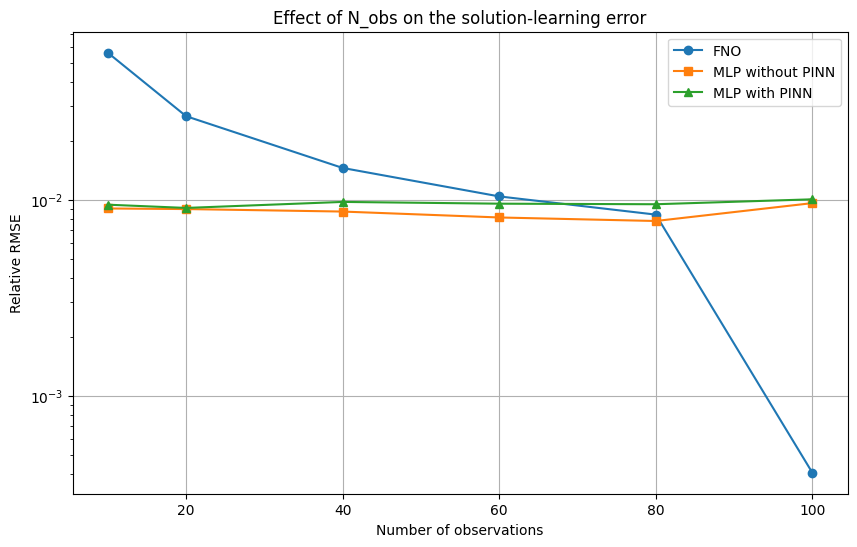

In [21]:
%autoreload 2

n_obs_values = np.array([10, 20, 40, 60, 80, 100])
fno_rmse_values = []
mlp_rmse_values = []
pinn_rmse_values = []

for n_obs in n_obs_values:
    k_true = torch.tensor([45, 38, 28, 22, 30, 45, 60, 75])
    collocation_points = torch.linspace(0, 1000, 100).view(-1, 1)
    ref_solution = compute_ref_solution(
        collocation_points,
        k=k_true,
        dx=10,
    )

    n_domain = ref_solution["domain"].shape[0]
    grid_indices = torch.linspace(0, n_domain - 1, steps=int(n_obs)).long()
    observation_points = torch.hstack((ref_solution["domain"], ref_solution["solution"]))[grid_indices]

    fno_model = FNO(
        device=device,
        n_modes_layer_1=20,
        n_modes_layer_2=20,
        n_channels=10,
        seed=0,
    )
    Trainer().fit(
        fno_model,
        collocation_points,
        observation_points,
        ref_solution,
        n_iter=300,
        lr=1e-2,
        display_freq=(500, 500),
    )

    mlp_model = MLP(
        device=device,
        layer_sizes=[1, 40, 1],
        seed=0,
    )
    Trainer(optimizer_name="lbfgs").fit(
        mlp_model,
        collocation_points,
        observation_points,
        ref_solution,
        n_iter=300,
        lr=1e-2,
        display_freq=(500, 500),
    )

    pinn_model = PINN(
        device=device,
        layer_sizes=[1, 40, 1],
        initial_k=k_true,
        seed=0,
        trainable_k=False,
    )
    PITrainer(train_k=False).fit(
        pinn_model,
        collocation_points,
        observation_points,
        ref_solution,
        pre_train_iter=100,
        alter_steps=4,
        alter_freq=(40, 0),
        scale_losses=True,
        display_freq=(500, 500),
    )

    h_true = ref_solution["solution"].numpy().flatten()
    with torch.no_grad():
        h_fno = fno_model(normalize_input(collocation_points, collocation_points)).numpy().flatten()
        h_mlp = mlp_model(normalize_input(collocation_points, collocation_points)).numpy().flatten()
        h_pinn = pinn_model(normalize_input(collocation_points, collocation_points)).numpy().flatten()

    fno_rmse_values.append(np.linalg.norm(h_fno - h_true, ord=2) / np.linalg.norm(h_true, ord=2))
    mlp_rmse_values.append(np.linalg.norm(h_mlp - h_true, ord=2) / np.linalg.norm(h_true, ord=2))
    pinn_rmse_values.append(np.linalg.norm(h_pinn - h_true, ord=2) / np.linalg.norm(h_true, ord=2))

fno_results = {"model_kind": "fno", "n_obs": n_obs_values, "rmse": np.array(fno_rmse_values)}
mlp_results = {"model_kind": "mlp", "n_obs": n_obs_values, "rmse": np.array(mlp_rmse_values)}
pinn_results = {"model_kind": "pinn", "n_obs": n_obs_values, "rmse": np.array(pinn_rmse_values)}

np.savez(SRC / "n_obs_study_fno.npz", n_obs=fno_results["n_obs"], rmse=fno_results["rmse"], model_kind=fno_results["model_kind"])
np.savez(SRC / "n_obs_study_mlp.npz", n_obs=mlp_results["n_obs"], rmse=mlp_results["rmse"], model_kind=mlp_results["model_kind"])
np.savez(SRC / "n_obs_study_pinn.npz", n_obs=pinn_results["n_obs"], rmse=pinn_results["rmse"], model_kind=pinn_results["model_kind"])

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(fno_results["n_obs"], fno_results["rmse"], "o-", label="FNO")
ax.plot(mlp_results["n_obs"], mlp_results["rmse"], "s-", label="MLP without PINN")
ax.plot(pinn_results["n_obs"], pinn_results["rmse"], "^-", label="MLP with PINN")
ax.set_xlabel("Number of observations")
ax.set_ylabel("Relative RMSE")
ax.set_yscale("log")
ax.grid(True)
ax.legend()
ax.set_title("Effect of N_obs on the solution-learning error")
fig.savefig(SRC / "n_obs_study_comparison.png", bbox_inches="tight")
plt.show()

**Question:** How to interpret these results?